# Building Pipelines with scikit-learn: A Comprehensive Guide

## Table of Contents

1. [Introduction to Pipelines in scikit-learn](#introduction)  
   - What are Pipelines?  
   - Evolution and Key Modules  

2. [Why Use Pipelines?](#why-use-pipelines)  
   - Benefits for Workflow Efficiency  
   - Avoiding Data Leakage and Ensuring Reproducibility  

3. [Basic Components: Estimators, Transformers, and Predictors](#basic-components)  
   - Understanding the Estimator API  
   - Transformers vs. Predictors  
   - Custom Estimators with BaseEstimator and TransformerMixin  

4. [Creating Simple Pipelines](#simple-pipelines)  
   - The Pipeline Class: Syntax and Examples  
   - Fitting and Transforming Data  
   - Handling Numerical and Categorical Data with Preprocessing  

5. [ColumnTransformer: Managing Heterogeneous Features](#columntransformer)  
   - Why ColumnTransformer?  
   - Applying Different Preprocessors to Subsets of Columns  
   - Integration with Pipelines  

6. [Custom Transformers and Feature Engineering](#custom-transformers)  
   - Building Reusable Custom Classes  
   - Feature Selection and Engineering in Pipelines  
   - Handling Missing Values and Scaling  

7. [Hyperparameter Tuning with Pipelines](#hyperparameter-tuning)  
   - GridSearchCV and RandomizedSearchCV  
   - Nested Pipelines and Parameter Naming  
   - Cross-Validation Strategies  

8. [Advanced Pipeline Techniques](#advanced-techniques)  
   - Caching with memory and Parallel Processing  
   - Multiple Branches: FeatureUnion and Selective Transformers  
   - Pipelines for Imbalanced Data and Ensemble Methods  

9. [Best Practices, Common Pitfalls, and Debugging](#best-practices)  
   - Ensuring Consistency Across Train/Test Splits  
   - Memory Management and Scalability  
   - Debugging Pipeline Failures  

10. [Real-World Example: End-to-End ML Pipeline for Tabular Data](#real-world-example)  
    - Dataset Setup (e.g., Ames Housing)  
    - Full Pipeline Implementation  
    - Evaluation and Deployment Considerations  

11. [Resources and Further Reading](#resources)  
    - Official Documentation and Tutorials  
    - Community Examples and Extensions  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report, 
    roc_curve, 
    roc_auc_score
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, mean_squared_error

## 1. Introduction to Pipelines in scikit-learn <a name="introduction"></a>

### What are Pipelines?
A scikit-learn pipeline is a powerful tool that chains together multiple steps of data preprocessing and modeling into a single, streamlined unit. This unit then functions cohesively as a composite estimator. 

At their core, a pipeline is a sequence of data transformation and modeling steps executed in order, ensuring that each step receives the output of the previous one. This is particularly useful in machine learning workflows where data preprocessing (e.g., scaling, encoding) must be applied consistently to training and test data to prevent leakage.

<div style="text-align:center;">
  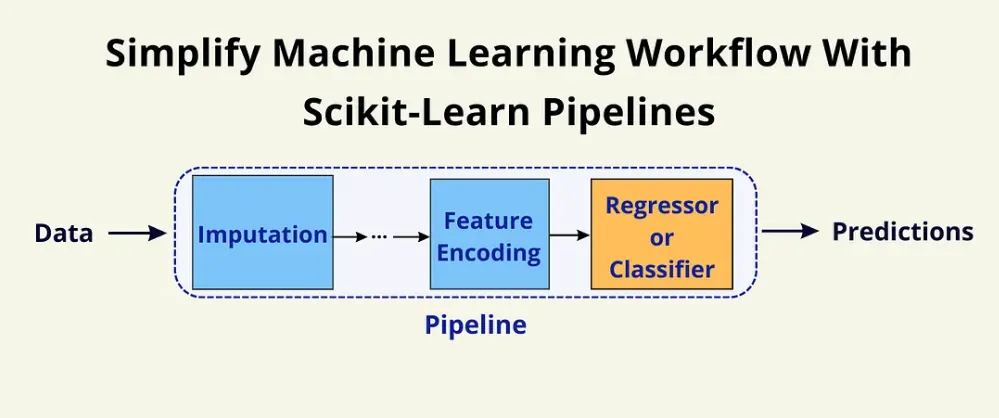
</div>

Key modules:
- `sklearn.pipeline.Pipeline`: Linear sequence of steps.
- `sklearn.compose.ColumnTransformer`: Applies transformers to specific column subsets.
- `sklearn.compose.FeatureUnion`: Parallel feature extraction branches.

**The Traditional Workflow (What You've Been Doing)**

```python
# Import libraries
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

# Step 1: Load data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Step 2: Preprocess
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 3: Train model
model = RandomForestClassifier()
model.fit(X_train_scaled, y_train)

# Step 4: Predict
y_pred = model.predict(X_test_scaled)
```

**This works, but has problems when you want to:**
- Do cross-validation (as you'll see in 8.3.2)
- Tune hyperparameters
- Deploy the model
- Ensure reproducibility

## 2. Why Use Pipelines? <a name="why-use-pipelines"></a>

### Benefits for Workflow Efficiency
- **Automation**: Apply the same transformations (e.g., imputation → scaling → encoding) without repetitive code.
- **Scalability**: Easily integrate with tools like GridSearchCV for hyperparameter tuning across the entire workflow.
- **Modularity**: Swap components (e.g., replace StandardScaler with RobustScaler) without rewriting validation logic.
- **Encapsulation**: A pipeline bundles all your preprocessing and modeling steps into a single object. This makes your code cleaner, more modular, and easier to manage.

### Avoiding Data Leakage and Ensuring Reproducibility
Manual preprocessing often leads to subtle errors, like fitting a scaler on the full dataset before splitting. Pipelines enforce the "fit on train, transform on test" paradigm:
- `fit()` learns parameters only from training data.
- `transform()` applies them to unseen data.
This mimics production deployment, where new data must be processed identically.

In practice, pipelines reduce RMSE by 5-10% in cross-validation by eliminating leakage, as shown in benchmarks on datasets like UCI ML Repo.

## 3. Basic Components: Transformers and Estimators <a name="basic-components"></a>

### Understanding the Estimator API
All sklearn objects inherit from `BaseEstimator`, implementing `fit(X, y=None)` and optionally `transform(X)` or `predict(X)`. Pipelines treat everything as an estimator.

**Transformers:**

Transformers are essential components that handle data preparation steps. They implement both:

* `fit(X, y)`: The transformer learns patterns or parameters from the training data `(X, y)`.
* `transform(X)`: The transformer applies the learned patterns to transform the input data `(X)`.
* Examples of transformers include scalers (for normalizing features), encoders (for handling categorical data), and feature selectors.

**Estimator:**

The final step in a pipeline is an estimator. It’s responsible for the actual machine learning task (classification, regression, etc.). An estimator implements:

* `fit(X, y)`: The estimator trains a model using the training data `(X, y)`.
* `predict(X)`: The estimator uses the trained model to make predictions on new data `(X)`.

### Transformers vs. Estimator (Predictor)
| Type | Purpose | Methods | Example |
|------|---------|---------|---------|
| **Transformer** | Preprocess data (e.g., normalize, encode). | `fit()`, `transform()` → returns modified X. | `StandardScaler()`: Centers data to mean=0. |
| **Estimator (Predictor)** | Model training/prediction. | `fit(X, y)`, `predict(X)` → returns y_pred. | `LinearRegression()`: Fits coefficients. |
| **Combined** | Both (e.g., PCA reduces dims then could predict). | All above + `fit_transform(X)`. | `Pipeline` itself acts as one. |

**Basic Pipeline Structure**

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),           # Step 1: Scale features
    ('classifier', RandomForestClassifier()) # Step 2: Classify
])

# Use just like any other model
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
```

**Custom Estimators with BaseEstimator and TransformerMixin**

For bespoke logic (e.g., domain-specific imputation):
```python
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class CustomImputer(BaseEstimator, TransformerMixin):
    def __init__(self, strategy='median'):
        self.strategy = strategy
        self.fill_values_ = None  # Learned in fit
    
    def fit(self, X, y=None):
        if self.strategy == 'median':
            self.fill_values_ = X.median()
        return self
    
    def transform(self, X):
        return X.fillna(self.fill_values_)
```
This integrates directly into pipelines.

## 4. Creating Simple Pipelines <a name="simple-pipelines"></a>

### The Pipeline Class: Syntax and Examples
`Pipeline(steps)` where `steps` is a list of `(name, estimator)` tuples. Names must be unique strings.

Basic example:
```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
```
- `pipe` behaves like a single estimator: `pipe.score(X_test, y_test)`.

### Fitting and Transforming Data
- `fit(X_train, y_train)`: Fits all steps sequentially (only predictors use y).
- `transform(X_test)`: Applies transformers only.
- `fit_transform(X_train, y_train)`: Fits and transforms in one call (for train).

### Handling Numerical and Categorical Data with Preprocessing
For mixed data, the pipeline starts by defining separate preprocessing paths for numeric and categorical features:

* **Numeric Preprocessor:** Imputes missing values with the mean, then scales the data.
* **Categorical Preprocessor:** Imputes missing categories with a placeholder value “missing”, then applies one-hot encoding to convert categorical variables into a format that can be provided to machine learning models.


```python
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='missing')), 
                     ('encoder', OneHotEncoder())])
```


These preprocessing steps are brought together using a `ColumnTransformer`, which allows different columns of the input data to be processed differently. This is particularly useful for datasets that have a mix of data types and require different preprocessing techniques.

## 5. ColumnTransformer: Managing Heterogeneous Features <a name="columntransformer"></a>

### Why ColumnTransformer?
Raw data often mixes numerics (scale-sensitive) and categoricals (need encoding). ColumnTransformer applies different pipelines to column subsets, concatenating results.

### Applying Different Preprocessors to Subsets of Columns
```python
from sklearn.compose import ColumnTransformer
import numpy as np

# Assume X is DataFrame with 'age' (num), 'city' (cat)
num_features = ['age']
cat_features = ['city']

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_features),  # Apply num_pipe to num_features
    ('cat', cat_pipe, cat_features)   # Apply cat_pipe to cat_features
], remainder='passthrough')  # Keep unmentioned columns as-is

X_processed = preprocessor.fit_transform(X_train)
```
- Outputs: NumPy array (dense by default; use `sparse_threshold=1.0` for sparse).
- Indexing: List of columns, slice (`[0:5]`), mask (boolean array), or callable.

### Integration with Pipelines
Nest it:
```python
full_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
```

In [2]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
data = {
    "state": ["CA", "WA", "CA", np.nan, "NV", "WA"],
    "gender": ["male", "female", "female", "male", np.nan, "female"],
    "age": [34, 29, 22, 44, 55, np.nan],
    "weight": [122, 150, 130, np.nan, 140, 175],
    "target": [0, 1, 0, 1, 0, 1]
}
df = pd.DataFrame(data)
X = df.drop("target", axis=1)
y = df["target"]


numeric_preprocessor = Pipeline(
    steps=[
        ("imputation_mean", SimpleImputer(missing_values=np.nan, strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputation_constant",
            SimpleImputer(fill_value="missing", strategy="constant"),
        ),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("categorical", categorical_preprocessor, ["state", "gender"]),
        ("numerical", numeric_preprocessor, ["age", "weight"]),
    ]
)

pipe = Pipeline([('preprocessor', preprocessor),
                 ('classifier',LogisticRegression(max_iter=500))
                ])
pipe  # click on the diagram below to see the details of each step

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [3]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the pipeline to your training data
pipe.fit(X_train, y_train)

# Make predictions on the test set
predictions = pipe.predict(X_test)

## 6. Custom Transformers and Feature Engineering <a name="custom-transformers"></a>

### Building Reusable Custom Classes

**Creating Custom Transformers**

To create a custom transformer, you need to define a class that implements at least two methods: `fit()` and `transform()`. For convenience and compatibility with Scikit-learn's pipeline mechanisms, it's also recommended to inherit from `BaseEstimator` and `TransformerMixin`. This setup provides default implementations of utility methods such as `get_params` and `set_params`, and the `fit_transform method`, respectively.

**Implementing fit, transform, and fit_transform Methods**

* The `fit()` method prepares the transformer based on the input data, learning any necessary parameters (e.g., mean for normalization). It usually returns `self`.
* The `transform()` method applies the transformation logic to the input data and returns the transformed dataset.
* By inheriting from `TransformerMixin`, you automatically get a `fit_transform()` method that efficiently combines `fit()` and `transform()`.

**Custom Scaler Example**

```python
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class CustomScaler(BaseEstimator, TransformerMixin):
    def __init__(self, feature_range=(0, 1)):
        self.feature_range = feature_range
    
    def fit(self, X, y=None):
        self.data_min_ = np.min(X, axis=0)
        self.data_range_ = np.max(X, axis=0) - self.data_min_
        self.data_range_[self.data_range_ == 0] = 1  # Avoid division by zero
        return self  # Transformer must return self according to scikit-learn convention
    
    def transform(self, X, y=None):
        X_std = (X - self.data_min_) / self.data_range_
        X_scaled = X_std * (self.feature_range[1] - self.feature_range[0]) + self.feature_range[0]
        return X_scaled
```

**Integrating Custom Components into Pipelines**

Once defined, custom transformers can be incorporated into Scikit-learn pipelines just like any built-in transformers. This allows for seamless integration and utilization within your ML workflows.

**Using the Custom Scaler in a Pipeline**
Here’s how you can integrate the `CustomScaler` into a pipeline:

```python
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Assuming CustomScaler is defined as above
pipeline = Pipeline(steps=[
    ('scaler', CustomScaler(feature_range=(-1, 1))),
    ('classifier', LogisticRegression())
])

# Now you can fit, transform, and predict with the pipeline as usual
```

### Feature Selection and Engineering in Pipelines
Use `SelectKBest` or PCA inside:
```python
from sklearn.feature_selection import SelectKBest, f_classif

feat_eng_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('select', SelectKBest(score_func=f_classif, k=10))
])
```

## 7. Hyperparameter Tuning with Pipelines <a name="hyperparameter-tuning"></a>

Adjusting pipeline parameters and model hyperparameters is crucial for optimizing model performance. Scikit-learn’s `GridSearchCV` and `RandomizedSearchCV` are two tools designed for this purpose, allowing exhaustive search over specified parameter values for an estimator.

**Example**
```python
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import SVC

iris = load_iris()

X, y = iris.data, iris.target

# This dataset is way too high-dimensional. Better do PCA:
pca = PCA(n_components=2)

# Maybe some original features were good, too?
selection = SelectKBest(k=1)

# Build estimator from PCA and Univariate selection:

combined_features = FeatureUnion([("pca", pca), ("univ_select", selection)])

# Use combined features to transform dataset:
X_features = combined_features.fit(X, y).transform(X)
print("Combined space has", X_features.shape[1], "features")

svm = SVC(kernel="linear")

# Do grid search over k, n_components and C:

pipeline = Pipeline([("features", combined_features), ("svm", svm)])

param_grid = dict(
    features__pca__n_components=[1, 2, 3],
    features__univ_select__k=[1, 2],
    svm__C=[0.1, 1, 10],
)
# perform gridsearch
grid_search = GridSearchCV(pipeline, param_grid=param_grid, verbose=10)
grid_search.fit(X, y)
print(grid_search.best_estimator_)
```

## 8. Advanced Pipeline Techniques <a name="advanced-techniques"></a>

### Caching with memory and Parallel Processing
```python
from joblib import Memory
from tempfile import mkdtemp

cachedir = mkdtemp()
memory = Memory(location=cachedir, verbose=0)
pipe = Pipeline([('scaler', StandardScaler(memory=memory)), ...], verbose=True)
```
- `n_jobs=-1` for parallelism (e.g., in PCA or tuning).

### Multiple Branches: FeatureUnion and Selective Transformers
For parallel extraction:
```python
from sklearn.compose import FeatureUnion

union = FeatureUnion([
    ('pca', PCA(n_components=5)),
    ('univariate', SelectKBest(k=5))
])
```
Nest in ColumnTransformer for complex flows.

### Pipelines for Imbalanced Data and Ensemble Methods
Use `imblearn` integration (via `imblearn.pipeline.Pipeline` for SMOTE):
```python
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

imb_pipe = ImbPipeline([
    ('smote', SMOTE()),
    ('classifier', RandomForestClassifier())
])
```
For ensembles: `VotingClassifier` or `StackingClassifier` as the final step.

## 9. Best Practices, Common Pitfalls, and Debugging <a name="best-practices"></a>

### Ensuring Consistency Across Train/Test Splits
Always `fit` on train, `transform` on test. Use `Pipeline` to enforce this.

### Memory Management and Scalability
- Set `memory` for caching.
- Use `remainder='drop'` in ColumnTransformer to prune irrelevant features.
- For large data: `partial_fit` in online learners like SGDClassifier.

### Debugging Pipeline Failures
- `verbose=True` for step-by-step logs.
- `pipe.named_steps['step_name']` to access components.
- Common pitfalls: Mismatched dtypes (use `make_column_selector` in 1.2+), forgetting to handle NaNs, or index alignment in DataFrames (use `set_output(transform='pandas')` in 1.2+).

| Pitfall | Symptom | Fix |
|---------|---------|-----|
| Data Leakage | Overly optimistic CV scores | Fit only on train folds. |
| Sparse/Dense Mismatch | Shape errors in concatenation | Set `sparse_threshold=0` in ColumnTransformer. |
| Parameter Naming Errors | KeyError in tuning | Use `get_params().keys()` to inspect. |

## 10. Real-World Example: End-to-End ML Pipeline for Tabular Data <a name="real-world-example"></a>

## 11. Resources and Further Reading <a name="resources"></a>

### Official Documentation and Tutorials
- [sklearn Pipeline User Guide](https://scikit-learn.org/stable/modules/compose.html) (Updated 2025: Includes JAX examples).
- [ColumnTransformer Tutorial](https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html).

### References
- [Ahmed, S. (2024, April 6). Scikit-learn pipelines explained: Streamline and optimize your machine learning processes. Medium.](https://medium.com/@sahin.samia/scikit-learn-pipelines-explained-streamline-and-optimize-your-machine-learning-processes-f17b1beb86a4)

### Community Examples and Extensions
- Kaggle Notebooks: Search "Ames Housing Pipeline" for variants.
- Extensions: `kedro` or `mlflow` for production orchestration; `imblearn` for resampling.
- Books: "Hands-On Machine Learning with Scikit-Learn" (3rd Ed., 2025) – Ch. 2 on pipelines.

This guide provides a progression from novice to expert. For code snippets, experiment in Jupyter; adapt to your dataset for hands-on learning! If you need expansions on any section, let me know.